# Shipping Container Delivery Performance Analysis

## Introduction

Timely delivery is a key performance indicator in logistics and supply chain management. Delays can increase operational costs, reduce customer satisfaction, and impact overall business performance.

This project analyzes container shipment data to evaluate delivery performance by comparing predicted and actual delivery dates. The analysis focuses on identifying delivery trends, measuring prediction accuracy, evaluating vessel and route performance, and examining monthly delivery patterns.

The project demonstrates a complete data analysis workflow, including data cleaning, feature engineering, exploratory data analysis, business KPI calculation, and data visualization using Python and Pandas.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Dataset

The analysis is based on a publicly available container shipment tracking dataset obtained from Kaggle. The dataset contains shipment information, including container identifiers, vessel names, ports of loading and discharge, predicted delivery dates, and actual delivery dates.

In [8]:
%pip install kagglehub 
%pip install openpyxl


import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download(
    "muzammalnawaz/container-tracking-data-set"
)

file_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_excel(file_path)
df.head()

,CONTAINER_NUMBER,VESSEL_NAME,FREIGHT_FORWARDER,PLACE_OF_DISPATCH,PORT_OF_LOADING,PORT_OF_DISCHARGE,POST_PORT_OF_DISCHARGE,PLACE_OF_DISPATCH_DATE,PORT_OF_LOADING_DATE,PORT_OF_DISCHARGE_DATE,POST_PORT_OF_DISCHARGE_DATE,PREDICTED_DELIVERED_DATE,LAST_TRACKED_WITH_VESSEL,DELIVERED_FLAG,DELIVERED_DATE,Another NEW Predicated Delivery Date
0,FCIU8573349,CAPE SOUNIO,CIF,"Yantian, Guangdong Sheng, China","Yantian, Guangdong Sheng, China","Long Beach, California, United States","Dallas, Texas, United States",2021-05-18,2021-05-19 00:00:00,2021-07-17,2021-07-15,2021-08-03,2021-08-03,Yes,2021-07-21,?
1,TGBU9903815,CAPE SOUNIO,CIF,"Yantian, Guangdong Sheng, China","Yantian, Guangdong Sheng, China","Long Beach, California, United States","Dallas, Texas, United States",2021-05-18,2021-05-19 00:00:00,2021-07-23,2021-07-21,2021-08-09,2021-07-26,Yes,2021-07-27,?
2,TCNU3242533,OOCL LUXEMBOURG,Axiom,"Shanghai, Shanghai Shi, China","Shanghai, Shanghai Shi, China","Long Beach, California, United States","Gainesville, Texas, United States",2021-04-11,2021-04-17 00:00:00,2021-05-05,2021-06-07,2021-06-11,2021-06-20,Yes,2021-06-16,?
3,FCIU8623774,MSC ORION,LF,"Vung Tau, Tinh Ba Ria-Vung Tau, Vietnam","Ho Chi Minh City, Ho Chi Minh City, Vietnam","Long Beach, California, United States","Dallas, Texas, United States",2021-05-19,2021-05-20 00:00:00,2021-07-15,2021-07-12,2021-07-19,2021-08-24,Yes,2021-07-20,?
4,FCIU9776905,COSCO ENGLAND,CIF,"Yantian, Guangdong Sheng, China","Yantian, Guangdong Sheng, China","Long Beach, California, United States","Gainesville, Texas, United States",2021-05-18,2021-05-24 00:00:00,2021-06-11,2021-06-22,2021-06-26,2021-06-26,Yes,2021-06-28,?


## Data Quality Check

Before analyzing delivery performance, the dataset was checked for missing values and unrealistic records that could distort the results.

Only shipments with both predicted and actual delivery dates were included in the analysis. Records containing missing delivery dates were removed because delivery delays could not be calculated.

Next, the delivery delay (`delay_days`) was calculated as the difference between the actual delivery date and the predicted delivery date. A positive value indicates a late delivery, while a negative value indicates an early delivery.

The dataset was examined for extreme values in the `delay_days` variable. Several records contained unrealistic delivery delays exceeding 1,000 days, which were traced to invalid predicted delivery dates (for example, dates in the year 1900). These records represent data quality issues rather than actual shipment delays.

To ensure reliable analysis, records with delivery delays outside the range of **-90 to 365 days** were treated as outliers and removed.

In [23]:
# Calculate delivery delay
df["delay_days"] = (
    df["DELIVERED_DATE"] -
    df["PREDICTED_DELIVERED_DATE"]
).dt.days


delivery_df = df.dropna(
    subset=[
        "PREDICTED_DELIVERED_DATE",
        "DELIVERED_DATE"
    ]
).copy()

print("Potential outliers:")
print(
    delivery_df.loc[
        delivery_df["delay_days"] > 1000,
        [
            "CONTAINER_NUMBER",
            "PREDICTED_DELIVERED_DATE",
            "DELIVERED_DATE",
            "delay_days"
        ]
    ]
)

# Remove unrealistic records
delivery_clean = delivery_df[
    delivery_df["delay_days"].between(-90, 365)
].copy()

print(f"\nOriginal records: {len(delivery_df)}")
print(f"Clean records: {len(delivery_clean)}")
print(f"Removed outliers: {len(delivery_df) - len(delivery_clean)}")

Potential outliers:
     CONTAINER_NUMBER PREDICTED_DELIVERED_DATE DELIVERED_DATE  delay_days
546       OOLU8357666               2018-07-29     2021-09-02      1131.0
778       TCNU3264173               1900-01-05     2021-09-10     44443.0
789       XHCU5229145               1900-01-01     2021-12-22     44550.0
949       EITU1334562               1900-01-05     2021-09-09     44442.0
1328      SUDU8889207               1900-01-01     2021-12-02     44530.0

Original records: 972
Clean records: 952
Removed outliers: 20


### Data Cleaning Summary

- Original records: **972**
- Records after removing outliers: **952**
- Outliers removed: **20**

The cleaned dataset (`delivery_clean`) was used for all subsequent analyses.

## Feature Engineering

To support delivery performance analysis, several new features were created from the original dataset.

First, all shipment date columns were converted to the `datetime` format to enable accurate date calculations.

Additional business-oriented features were then created:

- **delivery_status** – classifies each shipment as **Early**, **On Time**, **Late**, or **Unknown** based on the calculated delivery delay.
- **route** – combines the port of loading and port of discharge into a single route identifier for route-level analysis.
- **delivery_month** – extracts the delivery month from the actual delivery date to support monthly trend analysis.

These engineered features provide the foundation for the subsequent analysis of delivery performance, prediction accuracy, vessel performance, shipping routes, and monthly delivery trends.

In [24]:
# Convert date columns
date_columns = [
    "PLACE_OF_DISPATCH_DATE",
    "PORT_OF_LOADING_DATE",
    "PORT_OF_DISCHARGE_DATE",
    "POST_PORT_OF_DISCHARGE_DATE",
    "PREDICTED_DELIVERED_DATE",
    "LAST_TRACKED_WITH_VESSEL",
    "DELIVERED_DATE"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")


# Delivery status
df["delivery_status"] = df["delay_days"].apply(
    lambda x:
        "Unknown" if pd.isna(x)
        else "Early" if x < 0
        else "On Time" if x == 0
        else "Late"
)

# Route
df["route"] = (
    df["PORT_OF_LOADING"].fillna("Unknown").astype(str)
    + " → "
    + df["PORT_OF_DISCHARGE"].fillna("Unknown").astype(str)
)

# Delivery month
df["delivery_month"] = (
    df["DELIVERED_DATE"].dt.to_period("M")
)

## Delivery performanc

### Business Question

How reliably were shipments delivered relative to their predicted delivery dates?

To answer this question, the analysis evaluates three key performance indicators:

- **On-time delivery rate** – the percentage of shipments delivered on or before the predicted delivery date.
- **Average delivery delay** – the average difference between the predicted and actual delivery dates across all shipments.
- **Average delay for late shipments** – the average number of days shipments were delayed when they arrived after the predicted delivery date.

The delivery status distribution further illustrates the proportion of shipments delivered early, on time, and late.

In [25]:
on_time_rate = (
    (delivery_clean["delay_days"] <= 0)
    .mean()
    *100
)

average_delivery_delay = (
    delivery_clean["delay_days"].mean()
)

average_late_delay = (
    delivery_clean.loc[
        delivery_clean["delay_days"] > 0,
        "delay_days"
    ].mean()
)

print("\nResults:")
print(f"On-time delivery rate: {on_time_rate:.2f}%")
print(f"Average delivery delay: {average_delivery_delay:.2f} days")
print(f"Average delay (late shipments only): {average_late_delay:.2f} days")


Results:
On-time delivery rate: 40.13%
Average delivery delay: 0.01 days
Average delay (late shipments only): 6.59 days


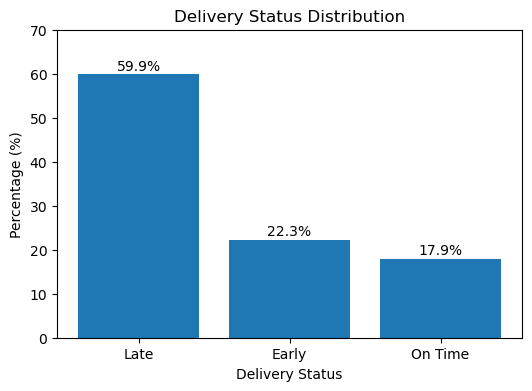

In [26]:
status_percentages = (
    delivery_clean["delivery_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


plt.figure(figsize=(6,4))

bars = plt.bar(
    status_percentages.index,
    status_percentages.values
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage (%)")
plt.ylim(0,70)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.show()

### Key Insight

Approximately **40.13%** of shipments were delivered on or before the predicted delivery date, while nearly **60%** arrived later than expected.

Although late deliveries were common, the average delay among late shipments was **6.59 days**, indicating that most delays were relatively short rather than extreme.

The overall average delivery delay across all shipments was **0.01 days**, suggesting that early and late deliveries largely balanced each other when considered together.

## Prediction Accuracy

### Business Question

How accurate were the predicted delivery dates?

To evaluate forecasting performance, two key metrics were calculated:

- **Exact prediction accuracy** – the percentage of shipments delivered on the exact predicted date.
- **Average prediction error** – the average absolute difference, in days, between the predicted and actual delivery dates.

These metrics assess the quality of delivery date predictions independently of whether shipments arrived early or late.

In [27]:
delivery_clean["prediction_error"] = (
    delivery_clean["DELIVERED_DATE"]
    - delivery_clean["PREDICTED_DELIVERED_DATE"]
).dt.days.abs()

exact_prediction_rate = (
    (delivery_clean["prediction_error"] == 0)
    .mean()
    * 100
)
average_prediction_error = (
    delivery_clean["prediction_error"].mean()
)
print("\nResults:")
print(f"Exact prediction accuracy: {exact_prediction_rate:.2f}%")
print(f"Average prediction error: {average_prediction_error:.2f} days")


Results:
Exact prediction accuracy: 17.86%
Average prediction error: 7.89 days


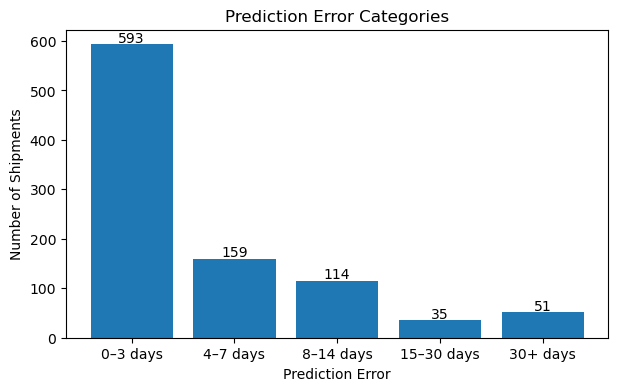

In [34]:
plt.figure(figsize=(7,4))

bars = plt.bar(
    error_counts.index.astype(str),
    error_counts.values
)

plt.title("Prediction Error Categories")
plt.xlabel("Prediction Error")
plt.ylabel("Number of Shipments")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{int(bar.get_height())}",
        ha="center"
    )

plt.show()

### Key Insight

Only **17.86%** of shipments were delivered on the exact predicted date, indicating that exact delivery forecasts were relatively uncommon.

The average prediction error was **7.89 days**, meaning that actual delivery dates differed from predictions by approximately one week on average.

The prediction error distribution shows that most shipments had relatively small forecasting errors, while a smaller number of shipments experienced substantially larger deviations. This suggests that delivery estimates were generally reasonable for most shipments but could be significantly inaccurate in certain cases.

## Vessel and Route Performance

### Business Question

Which vessels and shipping routes experience the highest delivery delays?

To answer this question, shipment performance was analyzed by vessel and shipping route. For each group, the following metrics were calculated:

- **Number of shipments** – to ensure reliable comparisons.
- **Average delivery delay** – the average number of days shipments were delivered early or late.
- **On-time delivery rate** – the percentage of shipments delivered on or before the predicted delivery date.

Only vessels and routes with at least **five completed shipments** were included in the analysis to reduce the impact of small sample sizes.

In [35]:
def performance_summary(df, group_column, minimum_shipments=5):
    performance = (
        df.groupby(group_column)
        .agg(
            shipments=("CONTAINER_NUMBER", "count"),
            average_delay=("delay_days", "mean"),
            on_time_rate=(
                "delay_days",
                lambda x: (x <= 0).mean() * 100
            )
        )
        .reset_index()
    )

    performance = performance[
        performance["shipments"] >= minimum_shipments
    ].copy()

    performance["average_delay"] = (
        performance["average_delay"].round(2)
    )

    performance["on_time_rate"] = (
        performance["on_time_rate"].round(2)
    )

    return performance


vessel_performance = performance_summary(
    delivery_clean,
    "VESSEL_NAME",
    minimum_shipments=5
)

route_performance = performance_summary(
    delivery_clean,
    "route",
    minimum_shipments=5
)

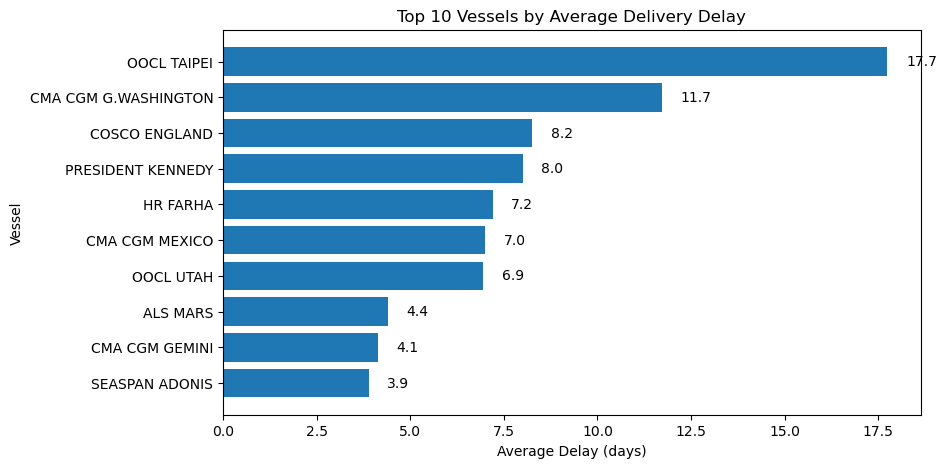

In [36]:
top_vessels = (
    vessel_performance
    .sort_values("average_delay", ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))

bars = plt.barh(
    top_vessels["VESSEL_NAME"],
    top_vessels["average_delay"]
)

plt.title("Top 10 Vessels by Average Delivery Delay")
plt.xlabel("Average Delay (days)")
plt.ylabel("Vessel")

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width()+0.5,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center"
    )

plt.show()

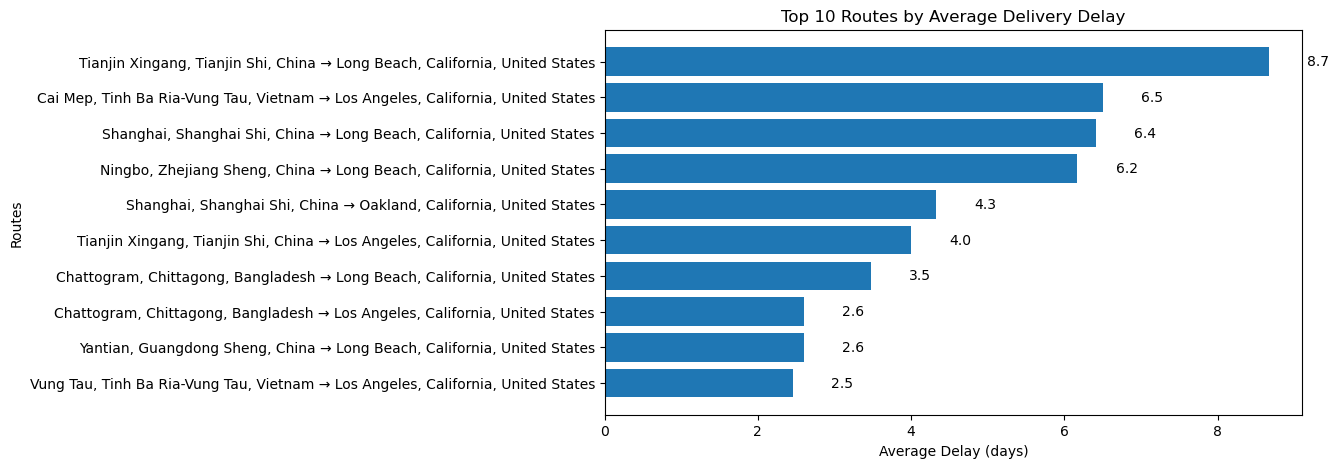

In [41]:
top_routes = (
    route_performance
    .sort_values("average_delay", ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))

bars = plt.barh(
    top_routes["route"],
    top_routes["average_delay"]
)

plt.title("Top 10 Routes by Average Delivery Delay")
plt.xlabel("Average Delay (days)")
plt.ylabel("Routes")

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width()+0.5,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center"
    )

plt.show()

### Key Insight

Performance varied across both vessels and shipping routes. Several vessels and routes consistently experienced higher average delivery delays than others.

These results suggest that delivery performance is influenced by operational factors such as vessel schedules, route characteristics, or port efficiency. Identifying consistently underperforming vessels and routes can help logistics teams prioritize operational improvements and improve delivery reliability.

## Monthly Delivery Performance

### Business Question

Did delivery performance change over time?

To identify monthly trends, shipment performance was analyzed by delivery month. For each month, the following metrics were calculated:

- **Number of shipments**
- **Average delivery delay**
- **On-time delivery rate**

Comparing these metrics helps determine whether delivery performance improved or deteriorated over the analyzed period.

In [42]:
monthly_performance = (
    delivery_clean
    .groupby("delivery_month")
    .agg(
        shipments=("CONTAINER_NUMBER", "count"),
        average_delay=("delay_days", "mean"),
        on_time_rate=("delay_days", lambda x: (x <= 0).mean() * 100)
    )
    .reset_index()
)
monthly_performance["average_delay"] = (
    monthly_performance["average_delay"].round(2)
)

monthly_performance["on_time_rate"] = (
    monthly_performance["on_time_rate"].round(2)
)
print("Monthly Delivery Performance")

display(
    monthly_performance.sort_values("delivery_month")
)

Monthly Delivery Performance


,delivery_month,shipments,average_delay,on_time_rate
0,2021-05,30,5.43,60.00
1,2021-06,95,-2.57,45.26
2,2021-07,146,-6.73,54.11
3,2021-08,106,-3.92,41.51
4,2021-09,100,0.40,48.00
5,2021-10,57,3.14,36.84
6,2021-11,83,0.98,54.22
7,2021-12,107,0.93,42.99
8,2022-01,149,5.01,22.82
9,2022-02,79,4.30,5.06


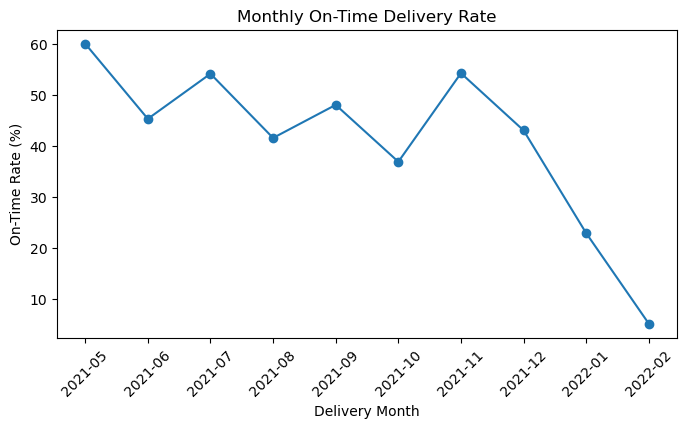

In [43]:
plt.figure(figsize=(8,4))

plt.plot(
    monthly_performance["delivery_month"].astype(str),
    monthly_performance["on_time_rate"],
    marker="o"
)

plt.title("Monthly On-Time Delivery Rate")
plt.xlabel("Delivery Month")
plt.ylabel("On-Time Rate (%)")
plt.xticks(rotation=45)

plt.show()

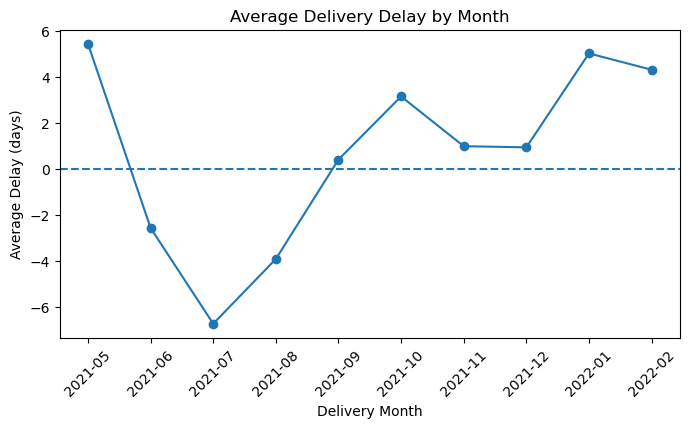

In [44]:
plt.figure(figsize=(8,4))

plt.plot(
    monthly_performance["delivery_month"].astype(str),
    monthly_performance["average_delay"],
    marker="o"
)

plt.title("Average Delivery Delay by Month")
plt.xlabel("Delivery Month")
plt.ylabel("Average Delay (days)")
plt.axhline(0, linestyle="--")

plt.xticks(rotation=45)

plt.show()

### Key Insight

Delivery performance varied across the analyzed months, with noticeable changes in both average delivery delay and on-time delivery rate.

The highest on-time delivery rate was observed in **May 2021 (60%)**, although this month contained the fewest shipments. In contrast, **January and February 2022** showed the lowest on-time delivery rates, indicating a decline in delivery performance during the final months of the observation period.

Because the dataset covers less than one year, these results highlight monthly variation rather than long-term seasonal trends.

# Conclusion

This project analyzed container shipment data to evaluate delivery performance and the accuracy of predicted delivery dates.

The analysis showed that only **40.13%** of shipments were delivered on or before the predicted delivery date, while most late shipments were delayed by an average of **6.59 days**. Although the overall average delivery delay was close to zero, this was due to early and late deliveries balancing each other.

Prediction accuracy was relatively low, with only **17.86%** of shipments arriving on the exact predicted date and an average prediction error of **7.89 days**. This indicates opportunities to improve delivery forecasting.

The analysis also identified vessels and shipping routes with consistently higher delivery delays, suggesting that operational performance varies across different parts of the logistics network. Monthly analysis further showed fluctuations in delivery performance over the observation period, although the available data is insufficient to draw conclusions about long-term seasonal patterns.

Overall, this project demonstrates how Python and Pandas can be used to clean data, engineer business-focused features, calculate key performance indicators, and visualize logistics performance to support data-driven decision-making.